<a href="https://colab.research.google.com/github/pe53127/Procesos-Gaussianos/blob/main/Proceso_Gaussiano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación de Proceso Gaussiano

Cargamos primero Numpy, matplotlib y math.

In [41]:
import numpy as np
from matplotlib import pyplot as plt
import math

# Simulaciones de la normal multivariante

Recordemos que un proceso estocástico se dice Gaussiano si la distribución finito dimensional en cualesquiera instantes sigue una distribución normal multivariante. Por ello, el primer objetivo es simular una normal multivariante.

En la siguiente celda vamos a obtener 50 muestras de una normal 3-dimensional con distribución $(X_1,X_2,X_3) → N(\textbf{0}, I_{3})$

In [42]:
vector_medias = np.zeros(3)
matriz_covarianzas = np.eye(3)
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples, check_valid='warn')

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[ 0.94024073  0.03545211 -1.00996342]
 [-1.17316714  2.31501209 -0.89449411]
 [ 0.70037364 -1.34581804  1.07644116]
 [ 0.05779789  1.0295431   0.38646837]
 [ 0.12145455 -1.36718365  0.360374  ]
 [ 0.51618812  0.17738726  0.86962279]
 [-1.64717978  0.60459233  0.87189381]
 [-1.06751005 -2.01291334 -1.5853632 ]
 [-0.88765499  0.26740336  1.11940579]
 [ 1.04855954  1.70248934 -0.53349158]
 [ 0.1657963   0.5594435  -0.82556348]
 [ 0.28804366 -0.7312116  -0.5494907 ]
 [-0.28175974 -0.26048115 -0.64118501]
 [-0.46257274  1.35114583 -0.5398203 ]
 [ 0.28985619 -0.19248701 -1.39869967]
 [ 0.99119816 -1.04078422  0.34072648]
 [ 0.55213203 -1.81455619  0.64125248]
 [-2.03737839  0.71591598  0.29603568]
 [ 0.64518578 -1.11523942 -0.85168934]
 [ 0.48861802  2.01690857 -0.90723825]
 [ 0.61208215  0.40524515  0.19860695]
 [-1.43759649  1.77339635  0.39011512]
 [ 0.11677459 -0.20122242  0.32388042]
 [-0.31952722 -0.98075746 -1.4554971 ]
 [-0.86865514  0.84083667  0.43766919

Vamos ahora a hacer lo mismo pero con matriz de covarianzas $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$

In [43]:
vector_medias =  np.zeros(3)
matriz_covarianzas = np.diag([1,10,100])
num_samples =50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples, check_valid='warn')

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[  1.34258289   1.34075318  -7.19032189]
 [ -0.06206645  -5.67808243  -6.9046109 ]
 [ -1.27564725   4.62299109   8.928929  ]
 [  2.17612795   3.2737308   -0.32687387]
 [ -0.70851417  -0.36328772   6.95727121]
 [ -1.45995203   3.94255055  -0.30864795]
 [ -0.93804699  -1.03573678  14.26156996]
 [ -0.91354899   3.66825924   3.78661488]
 [ -0.55627603   0.48086367  -2.66034711]
 [ -1.32354051   2.06969395 -20.10931102]
 [ -1.5551713   -2.11338526   3.25715866]
 [  0.7357814   -0.78240323   1.90904781]
 [  1.36824354   0.98121487   1.62022937]
 [ -0.29834769  -3.59224899  -6.83279942]
 [  0.18039722  -1.34464613   6.16919552]
 [  0.27606466  -4.93662363 -11.62918736]
 [ -0.66925319   5.29060248  -0.82053211]
 [  0.06903879   2.34510182   0.11278742]
 [  0.89186545   3.88118598   6.05158723]
 [  1.26573082   3.38370183  -6.51396358]
 [ -2.80654009  -3.58030763 -17.647492  ]
 [  1.41582629  -1.38139895  17.00435356]
 [ -0.99654123   4.42418047  -1.01376789]
 [  1.4

# Simulación con un kernel RBF

Recordemos que el Kernel RBF en dos instantes $t_1,t_2$ se define como $k(t_1,t_2)=\sigma^2\cdot exp(-\frac{1}{2}\cdot (\frac{t_1-t_2}{l})^2).$ Vamos a simularlo suponiendo que el vector de medias es el 0.

In [44]:
def simular_GP_RBF(t, sigma_sq, lengthscale, num_samples):
  # Comprobar que los datos son correctos:

  son_validos = np.all(np.isfinite(t))
  if not son_validos:
    print("No has introducido un vector de instantes válido.")
    return

  try:
    sigma_sq=float(sigma_sq) #Pasamos a número porque se introduce como string.
    if sigma_sq>0: #Comprobamos que la varianza es positiva.
      pass #Se sale del if si las líneas anteriores funcionan.
    else:
      print("El valor de la varianza no es correcto. Debe ser un número positivo.")
      return #Salimos de la función de simulación.

  except ValueError: #Por si no se ha introducido un número.
    print("No has introducido un número en la varianza.")
    return #Salimos de la función de simulación.

  try:
    lengthscale=float(lengthscale) #Pasamos a número porque se introduce como string.
    if lengthscale>0: #Comprobamos que p es un número positivo.
      pass #Se sale del if si las líneas anteriores funcionan.
    else:
      print("El valor de lengthscale no es correcto. Debe ser un número positivo.")
      return #Salimos de la función de simulación.

  except ValueError: #Por si no se ha introducido un número.
    print("No has introducido un número en lengthscale.")
    return #Salimos de la función de simulación.

  try:
    num_samples=int(num_samples) #Pasamos a número porque se introduce como string.
    if num_samples>0: #Comprobamos que p es un número entre 0 y 1.
      pass #Se sale del if si las líneas anteriores funcionan.
    else:
      print("El valor del número de muestras no es correcto. Debe ser un número natural.")
      return #Salimos de la función de simulación.

  except ValueError: #Por si no se ha introducido un número.
    print("No has introducido un número en el número de muestras.")
    return #Salimos de la función de simulación.

  # Paso 1: calculamos el vector de medias.
  vector_medias = np.zeros_like(t)

  # Paso 2: calculamos la matriz de covarianzas.
  matriz_covs = sigma_sq*np.exp(-0.5*(np.subtract.outer(t,t)/lengthscale)**2)

  # Paso 3: obtenemos las muestras/simulaciones del GP.
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples, check_valid='warn')

  return samples

## Diapositiva 59

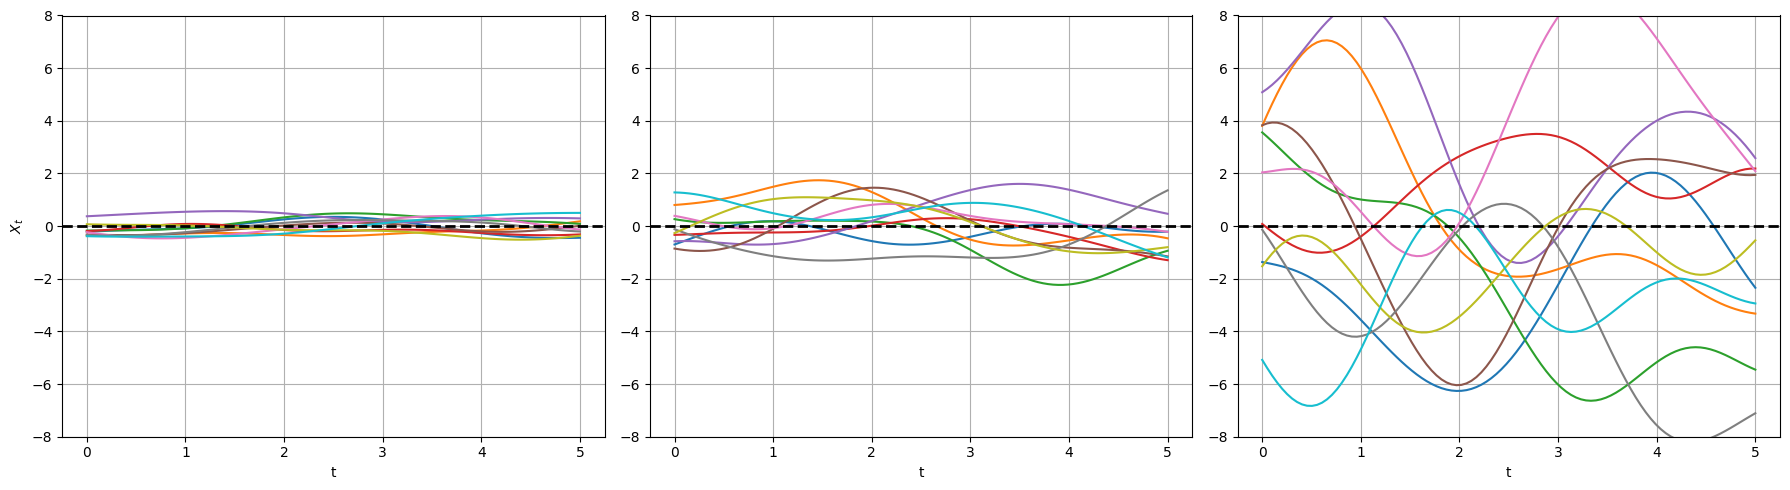

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
t=np.linspace(0,5,100)

# Primera gráfica
sigma_sq=0.25**2
lengthscale=1
num_samples=10
y1=simular_GP_RBF(t, sigma_sq, lengthscale, num_samples)

axes[0].plot(t,y1.T)
axes[0].grid(True)
axes[0].set_ylim(-8, 8)
axes[0].set_xlabel('t')
axes[0].set_ylabel(r'$X_t$')
axes[0].axhline(0, color='black', linestyle='--', linewidth=2)

# Segunda gráfica
sigma_sq=1
lengthscale=1
num_samples=10
y2=simular_GP_RBF(t, sigma_sq, lengthscale, num_samples)

axes[1].plot(t,y2.T)
axes[1].grid(True)
axes[1].set_ylim(-8, 8)
axes[1].set_xlabel('t')
axes[1].axhline(0, color='black', linestyle='--', linewidth=2)

# Tercera gráfica
sigma_sq=4**2
lengthscale=1
num_samples=10
y3=simular_GP_RBF(t, sigma_sq, lengthscale, num_samples)

axes[2].plot(t,y3.T)
axes[2].grid(True)
axes[2].set_ylim(-8, 8)
axes[2].set_xlabel('t')
axes[2].axhline(0, color='black', linestyle='--', linewidth=2)

# Ajustamos el espacio entre gráficas para que no se solapen las etiquetas
plt.tight_layout()
plt.show()

## Diapositiva 62

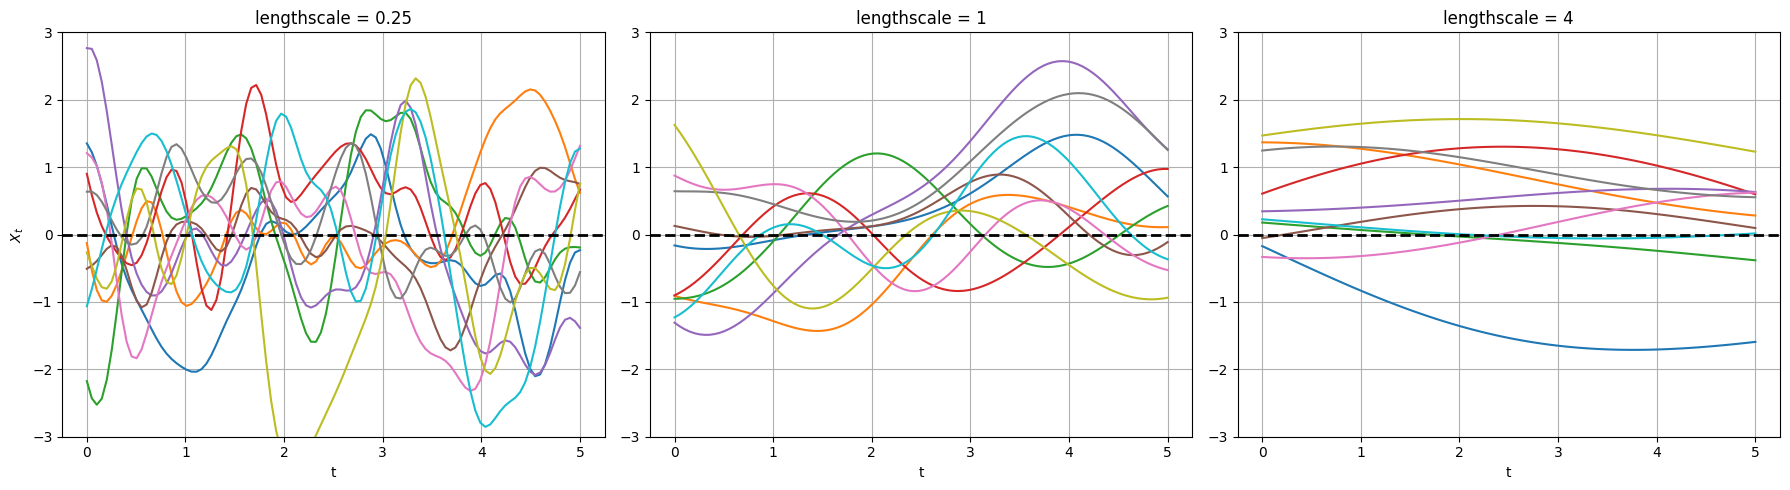

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
t=np.linspace(0,5,100)

# Primera gráfica
sigma_sq=1
lengthscale=0.25
num_samples=10
y1=simular_GP_RBF(t, sigma_sq, lengthscale, num_samples)

axes[0].plot(t,y1.T)
axes[0].grid(True)
axes[0].set_ylim(-3, 3)
axes[0].set_title('lengthscale = 0.25')
axes[0].set_xlabel('t')
axes[0].set_ylabel(r'$X_t$')
axes[0].axhline(0, color='black', linestyle='--', linewidth=2)

# Segunda gráfica
sigma_sq=1
lengthscale=1
num_samples=10
y2=simular_GP_RBF(t, sigma_sq, lengthscale, num_samples)

axes[1].plot(t,y2.T)
axes[1].grid(True)
axes[1].set_ylim(-3, 3)
axes[1].set_title('lengthscale = 1')
axes[1].set_xlabel('t')
axes[1].axhline(0, color='black', linestyle='--', linewidth=2)

# Tercera gráfica
sigma_sq=1
lengthscale=4
num_samples=10
y3=simular_GP_RBF(t, sigma_sq, lengthscale, num_samples)

axes[2].plot(t,y3.T)
axes[2].grid(True)
axes[2].set_ylim(-3, 3)
axes[2].set_title('lengthscale = 4')
axes[2].set_xlabel('t')
axes[2].axhline(0, color='black', linestyle='--', linewidth=2)

# Ajustamos el espacio entre gráficas para que no se solapen las etiquetas
plt.tight_layout()
plt.show()

# Simulación con un kernel períodico

Recordemos que un kernel períodico en dos instantes $t_1,t_2$ se define como $k(t_1,t_2)= \sigma^2 exp(-\frac{2}{l^2}sin^2(\pi \cdot \frac{|t_1 - t_2|}{p}))$

In [47]:
def simular_GP_periodic(t, sigma_sq, lengthscale, p, num_samples):
  son_validos = np.all(np.isfinite(t))
  if not son_validos:
    print("No has introducido un vector de instantes válido.")
    return

  try:
    sigma_sq=float(sigma_sq) #Pasamos a número porque se introduce como string.
    if sigma_sq>0: #Comprobamos que la varianza es positiva.
      pass #Se sale del if si las líneas anteriores funcionan.
    else:
      print("El valor de la varianza no es correcto. Debe ser un número positivo.")
      return #Salimos de la función de simulación.

  except ValueError: #Por si no se ha introducido un número.
    print("No has introducido un número en la varianza.")
    return #Salimos de la función de simulación.

  try:
    p=float(p) #Pasamos a número porque se introduce como string.
    if p>0: #Comprobamos que el período es positivo.
      pass #Se sale del if si las líneas anteriores funcionan.
    else:
      print("El valor del período no es correcto. Debe ser un número positivo.")
      return #Salimos de la función de simulación.

  except ValueError: #Por si no se ha introducido un número.
    print("No has introducido un número en el período.")
    return #Salimos de la función de simulación.

  try:
    lengthscale=float(lengthscale) #Pasamos a número porque se introduce como string.
    if lengthscale>0: #Comprobamos que lenghtscale es un número positivo.
      pass #Se sale del if si las líneas anteriores funcionan.
    else:
      print("El valor de lengthscale no es correcto. Debe ser un número positivo.")
      return #Salimos de la función de simulación.

  except ValueError: #Por si no se ha introducido un número.
    print("No has introducido un número en lengthscale.")
    return #Salimos de la función de simulación.

  try:
    num_samples=int(num_samples) #Pasamos a número porque se introduce como string.
    if num_samples>0: #Comprobamos que el número de muestras es positivo.
      pass #Se sale del if si las líneas anteriores funcionan.
    else:
      print("El valor del número de muestras no es correcto. Debe ser un número natural.")
      return #Salimos de la función de simulación.

  except ValueError: #Por si no se ha introducido un número.
    print("No has introducido un número en el número de muestras.")
    return #Salimos de la función de simulación.

  # Paso 1: calculamos el vector de medias.
  vector_medias = np.zeros_like(t)

  # Paso 2: calculamos la matriz de covarianzas.
  matriz_covs = sigma_sq*np.exp(-(2/(lengthscale**2))*(np.sin(np.pi*np.subtract.outer(t,t)/p))**2)

  # Paso 3: obtenemos las muestras/simulaciones del GP.
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples, check_valid='warn')

  return samples

## Diapositiva 72


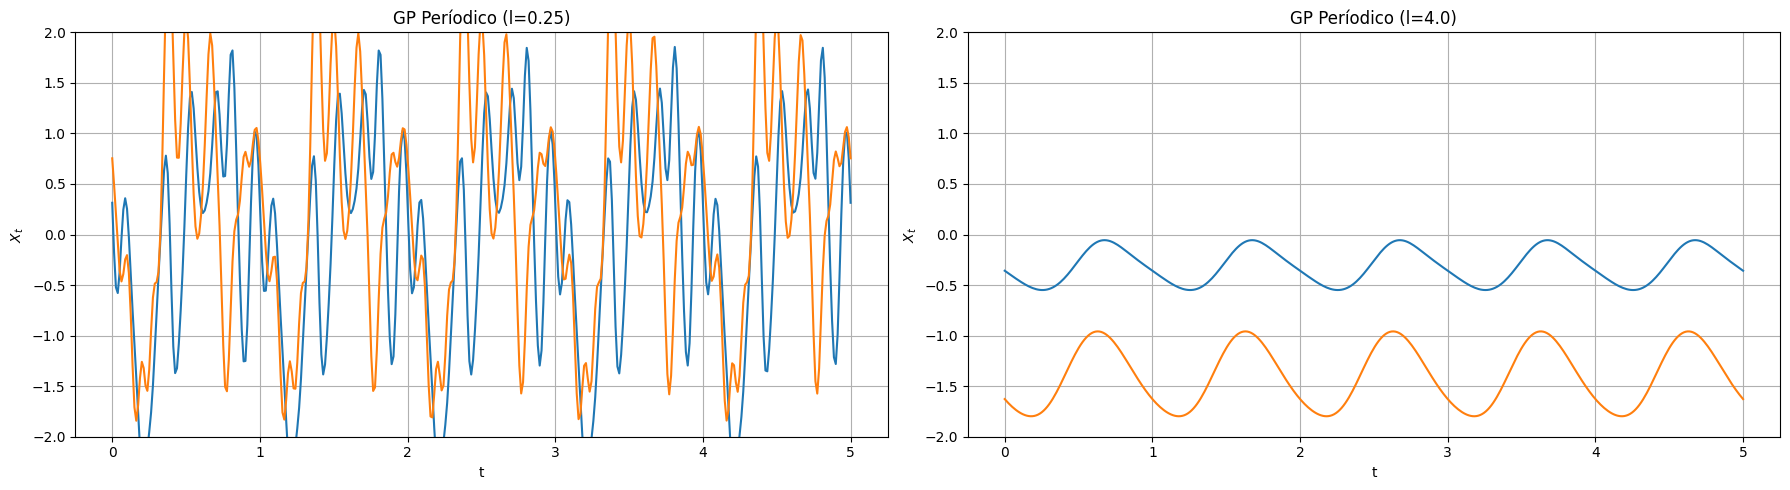

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
t=np.linspace(0,5,400)

# Primera gráfica
y1=simular_GP_periodic(t, 1, 0.25, 1, 2)
axes[0].plot(t,y1.T)
axes[0].set_title('GP Períodico (l=0.25)')
axes[0].grid(True)
axes[0].set_ylim(-2, 2)
axes[0].set_xlabel('t')
axes[0].set_ylabel(r'$X_t$')

# Segunda gráfica
y2=simular_GP_periodic(t, 1, 4, 1, 2)
axes[1].plot(t,y2.T)
axes[1].set_title('GP Períodico (l=4.0)')
axes[1].grid(True)
axes[1].set_ylim(-2, 2)
axes[1].set_xlabel('t')
axes[1].set_ylabel(r'$X_t$')

# Ajustamos el espacio entre gráficas para que no se solapen las etiquetas
plt.tight_layout()
plt.show()

## Diapositiva 74

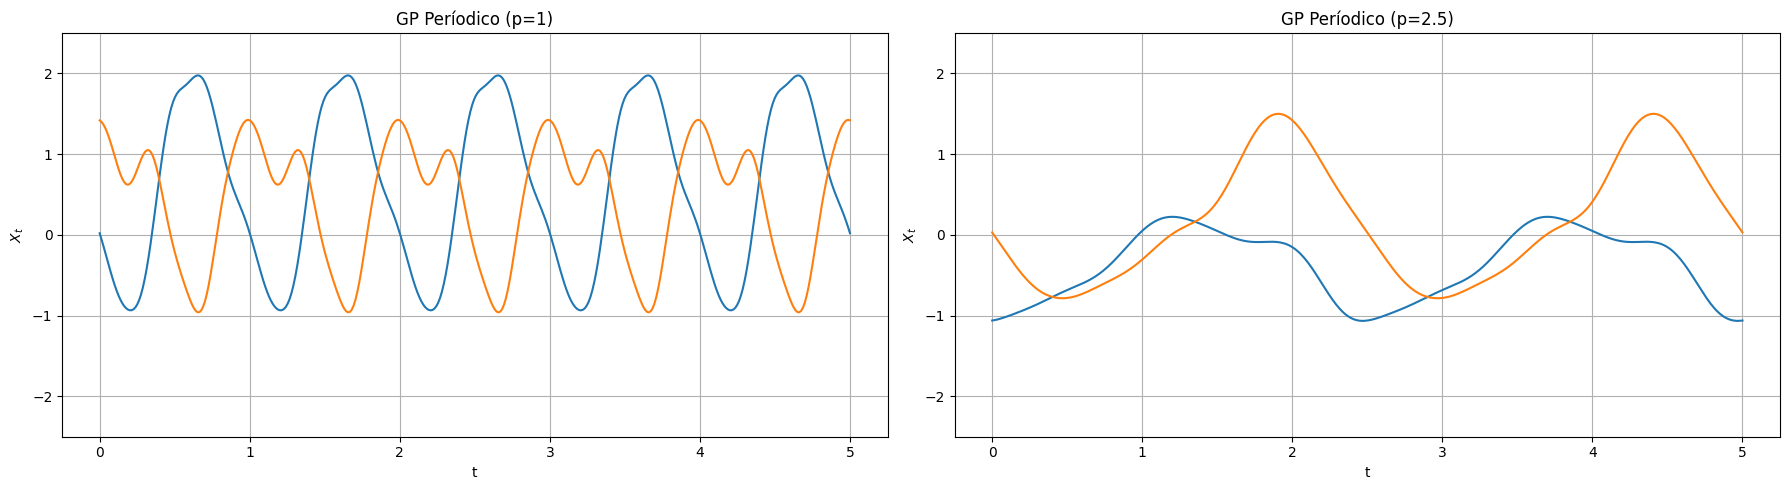

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
t=np.linspace(0,5,400)

# Primera gráfica
y1=simular_GP_periodic(t, 1, 1, 1, 2)
axes[0].plot(t,y1.T)
axes[0].set_title('GP Períodico (p=1)')
axes[0].grid(True)
axes[0].set_ylim(-2.5, 2.5)
axes[0].set_xlabel('t')
axes[0].set_ylabel(r'$X_t$')

# Segunda gráfica
y2=simular_GP_periodic(t, 1, 1, 2.5, 2)
axes[1].plot(t,y2.T)
axes[1].set_title('GP Períodico (p=2.5)')
axes[1].grid(True)
axes[1].set_ylim(-2.5, 2.5)
axes[1].set_xlabel('t')
axes[1].set_ylabel(r'$X_t$')

# Ajustamos el espacio entre gráficas para que no se solapen las etiquetas
plt.tight_layout()
plt.show()


## Diapositiva 76

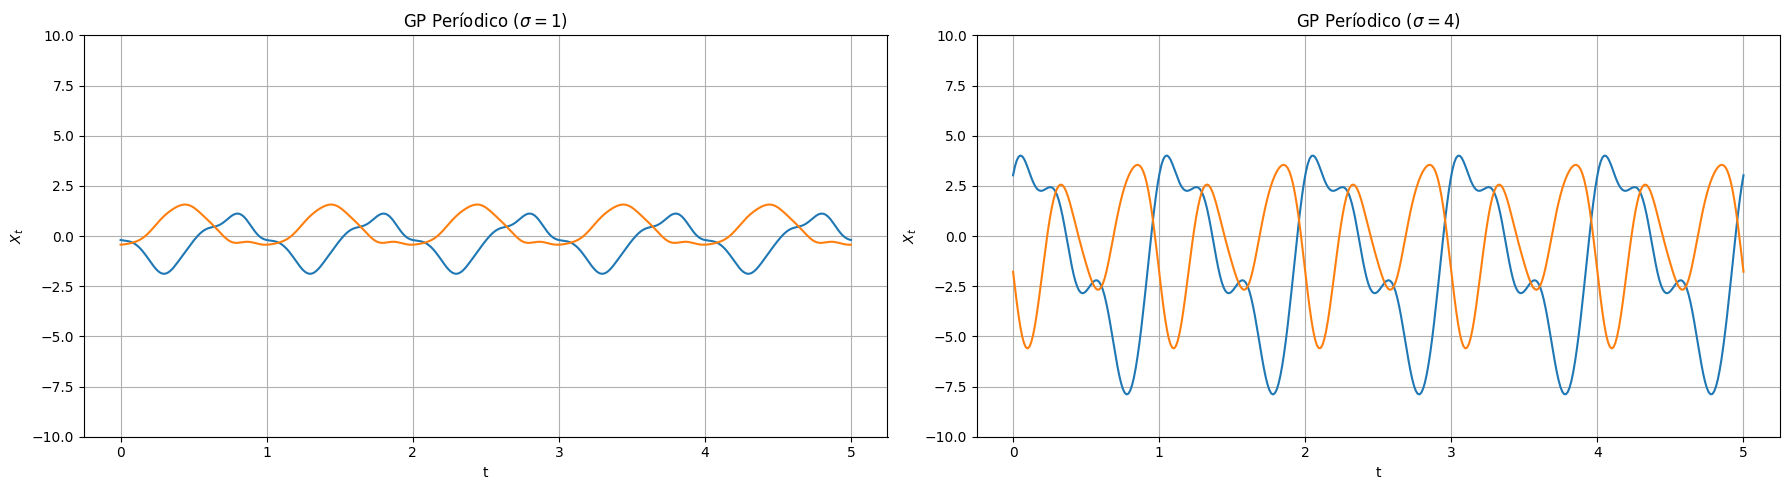

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
t=np.linspace(0,5,400)

# Primera gráfica
y1=simular_GP_periodic(t, 1, 1, 1, 2)
axes[0].plot(t,y1.T)
axes[0].set_title(r'GP Períodico ($\sigma=1$)')
axes[0].grid(True)
axes[0].set_ylim(-10, 10)
axes[0].set_xlabel('t')
axes[0].set_ylabel(r'$X_t$')

# Segunda gráfica
y2=simular_GP_periodic(t, 16, 1, 1, 2)
axes[1].plot(t,y2.T)
axes[1].set_title(r'GP Períodico ($\sigma=4$)')
axes[1].grid(True)
axes[1].set_ylim(-10, 10)
axes[1].set_xlabel('t')
axes[1].set_ylabel(r'$X_t$')

# Ajustamos el espacio entre gráficas para que no se solapen las etiquetas
plt.tight_layout()
plt.show()


# Simulación con un kernel DPK

Recordemos que el kernel DPK se define de la siguiente manera: dadas $f_1,\dots, f_m$ funciones de T a $\mathbb{R}$ definimos el kernel DPK asociado a estas funciones como $k(t_1,t_2)=\sum_{i=1}^{m}f_i(t_1)\cdot f_i(t_2)$. En este caso, las funciones que vamos a coger son $1,t,t^2,\dots,t^m$.

In [51]:
def simular_GP_DPKpoly(t, m, num_samples):

  son_validos = np.all(np.isfinite(t))
  if not son_validos:
    print("No has introducido un vector de instantes válido.")
    return

  try:
    m=int(m) #Pasamos a número porque se introduce como string.
    if m>0: #Comprobamos que la varianza es positiva.
      pass #Se sale del if si las líneas anteriores funcionan.
    else:
      print("El valor de m no es correcto. Debe ser un número positivo.")
      return #Salimos de la función de simulación.

  except ValueError: #Por si no se ha introducido un número.
    print("No has introducido un número en m.")
    return #Salimos de la función de simulación.

  try:
    num_samples=int(num_samples) #Pasamos a número porque se introduce como string.
    if num_samples>0: #Comprobamos que p es un número entre 0 y 1.
      pass #Se sale del if si las líneas anteriores funcionan.
    else:
      print("El valor del número de muestras no es correcto. Debe ser un número natural.")
      return #Salimos de la función de simulación.

  except ValueError: #Por si no se ha introducido un número.
    print("No has introducido un número en el número de muestras.")
    return #Salimos de la función de simulación.

  # Paso 1: calculamos el vector de medias.
  vector_medias = np.zeros_like(t)

  # Paso 2: calculamos la matriz de covarianzas.
  potencias=np.arange(m+1) #Aquí guardamos las potencias que van a actuar como las funciones base.

  a=t[:,np.newaxis] ** potencias #Hacemos que el vector de los instantes temporales sea columna. Luego, multiplicamos por el vector potencias. Como las dimensiones no son
  #correctas, se estira el vector columna con los mismos valores y ya se multiplica. Así, obtenemos una matriz donde cada fila es cada instante temporal evaluado en cada
  #función base.

  matriz_covs = np.dot(a, a.T) #Multiplicamos la matriz anterior por su traspuesta.

  # Paso 3: obtenemos las muestras/simulaciones del GP. Puede ocurrir que la matriz de covarianzas no sea definida positiva y que la función no funcione. Para arreglar esto,
  # añadimos un error mínimo a la matriz de covarianzas para que sea definida positiva.

  jitter = 1e-9 * np.eye(len(t))
  matriz_covs+=jitter

  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples, check_valid='warn')

  return samples

## Diapositiva 89

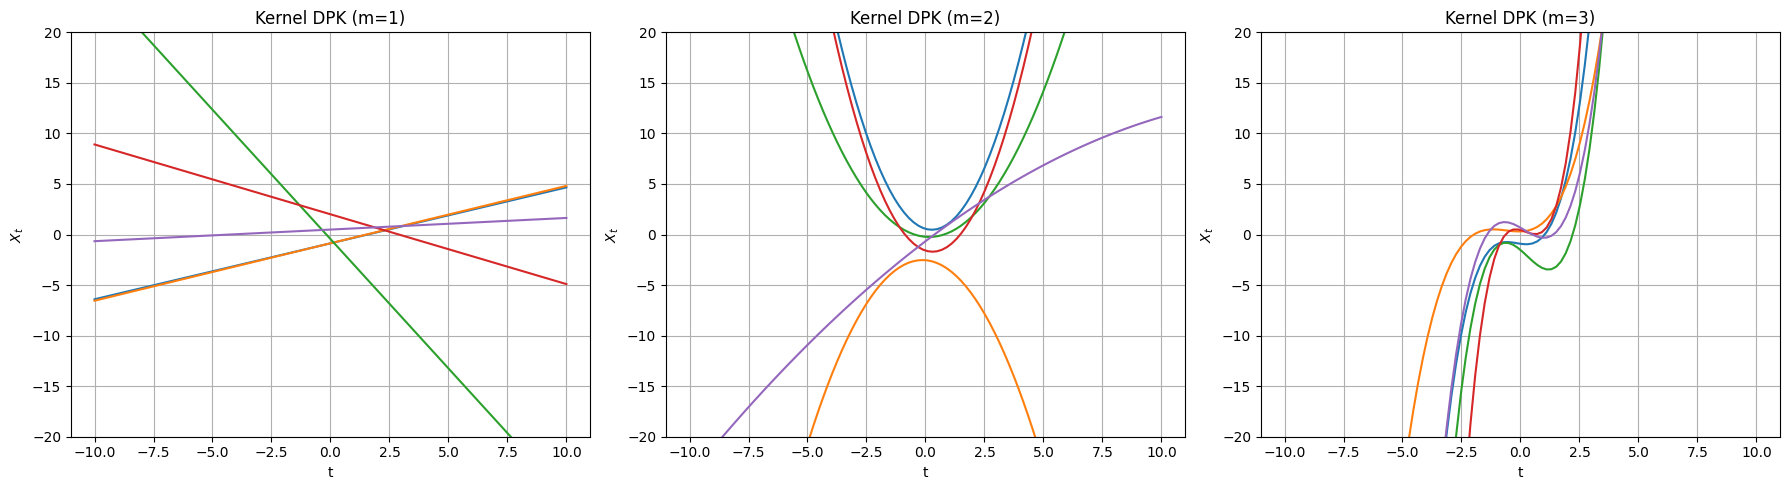

In [52]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
t=np.linspace(-10,10,100)

# Primera gráfica
y1=simular_GP_DPKpoly(t, 1, 5)
axes[0].plot(t,y1.T)
axes[0].set_title('Kernel DPK (m=1)')
axes[0].grid(True)
axes[0].set_ylim(-20, 20)
axes[0].set_xlabel('t')
axes[0].set_ylabel(r'$X_t$')

# Segunda gráfica
y2=simular_GP_DPKpoly(t, 2, 5)
axes[1].plot(t,y2.T)
axes[1].set_title('Kernel DPK (m=2)')
axes[1].grid(True)
axes[1].set_ylim(-20, 20)
axes[1].set_xlabel('t')
axes[1].set_ylabel(r'$X_t$')

# Tercera gráfica
y3=simular_GP_DPKpoly(t, 3, 5)
axes[2].plot(t,y3.T)
axes[2].set_title('Kernel DPK (m=3)')
axes[2].grid(True)
axes[2].set_ylim(-20, 20)
axes[2].set_xlabel('t')
axes[2].set_ylabel(r'$X_t$')

# Ajustamos el espacio entre gráficas para que no se solapen las etiquetas
plt.tight_layout()
plt.show()
